In [1]:
import numpy as np
import pandas as pd
import os
import textwrap

In [2]:
def load_data(data_dir, x_filename='x_train.csv', y_filename='y_train.csv'):
    x_train_df = pd.read_csv(os.path.join(data_dir, x_filename))
    y_train_df = pd.read_csv(os.path.join(data_dir, y_filename))

    N, n_cols = x_train_df.shape
    print("Shape of x_train_df: (%d, %d)" % (N, n_cols))
    print("Shape of y_train_df: %s" % str(y_train_df.shape))

    # Print out 8 random entries
    tr_text_list = x_train_df['text'].values.tolist()
    prng = np.random.RandomState(101)
    rows = prng.permutation(np.arange(y_train_df.shape[0]))
    for row_id in rows[:3]:
        text = tr_text_list[row_id]
        print("row %5d | %s BY %s | y = %s" % (
            row_id,
            y_train_df['title'].values[row_id],
            y_train_df['author'].values[row_id],
            y_train_df['Coarse Label'].values[row_id],
            ))
        # Pretty print text via textwrap library
        line_list = textwrap.wrap(tr_text_list[row_id],
            width=70,
            initial_indent='  ',
            subsequent_indent='  ')
        print('\n'.join(line_list))
        print("")
    return x_train_df, y_train_df

In [3]:
x_train_df, y_train_df = load_data(data_dir = "data", x_filename = "x_train.csv", y_filename = "y_train.csv")

Shape of x_train_df: (5557, 32)
Shape of y_train_df: (5557, 5)
row  4746 | The Red and the Black: A Chronicle of 1830 BY Stendhal | y = Key Stage 4-5
  It was hermetically sealed; he was on the point of  fainting and
  remained for a long time leaning against the oak; then  with a
  staggering step he went to have another look at the gardener's
  ladder. The chain which he had once forced asunder--in, alas, such
  different  circumstances--had not yet been repaired. Carried away by
  a moment of  madness, Julien pressed it to his lips.

row  1250 | Cranford BY Elizabeth Cleghorn Gaskell | y = Key Stage 4-5
  Miss Pole, Miss Matty, and I, meanwhile attended to Miss Brown: and
  hard  work we found it to relieve her querulous and never-ending
  complaints. But if we were so weary and dispirited, what must Miss
  Jessie have been! Yet she came back almost calm as if she had gained
  a new strength. She  put off her mourning dress, and came in,
  looking pale and gentle,  thanking us each 

In [4]:
import sklearn
from sklearn.feature_extraction.text import TfidfTransformer

def make_logit_pipeline(C=1.0, use_tfidf=True, sublinear_tf=True):
    """Construct a sklearn Pipeline that optionally applies TF-IDF to count features, then scales and fits a logistic regression."""
    steps = []
    if use_tfidf:
        steps.append(('tfidf', TfidfTransformer(sublinear_tf=sublinear_tf)))
    steps.extend([
        ('rescaler', sklearn.preprocessing.MaxAbsScaler()),
        ('logit', sklearn.linear_model.LogisticRegression(solver="lbfgs", l1_ratio=0, C=C, max_iter=1000))
    ])
    pipeline = sklearn.pipeline.Pipeline(steps=steps)
    return pipeline

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

def find_best_vocab(
    x_df=x_train_df, 
    y_labels=y_train_df['Coarse Label'], 
    min_df_range=(10, 51, 5), 
    max_df_range=np.arange(1.0, 0.4, -.1), 
    n_splits=10, 
    random_state=42
):
    hypers_list = []
    kf = sklearn.model_selection.KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    for min_df in min_df_range:
        for max_df in max_df_range:
            # Build feature matrix for this vocab
            # Use CountVectorizer to build count matrix; TF-IDF will be applied in the pipeline
            vectorizer = CountVectorizer(min_df=min_df, max_df=max_df)
            X_train = vectorizer.fit_transform(x_df['text'])
            analyze = vectorizer.build_analyzer()
            vocab = vectorizer.get_feature_names_out()
            X_counts = X_train.toarray()
            vocab_df = pd.DataFrame(X_counts, columns=vocab, index=x_df.index)
            
            # CV evaluation with this vocab
            pl = make_logit_pipeline(C=1.0)
            aucs = []
            for train_index, val_index in kf.split(vocab_df):
                x_train_fold = vocab_df.iloc[train_index]
                y_train_fold = y_labels.iloc[train_index]
                x_val_fold = vocab_df.iloc[val_index]
                y_val_fold = y_labels.iloc[val_index]
                
                pl.fit(x_train_fold, y_train_fold)
                y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]
                auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
                aucs.append(auc)
            
            mean_auc = np.mean(aucs)
            hypers_list.append((min_df, max_df, len(vocab), mean_auc))
    
    # Get best vocab bounds
    best_hypers_config = max(hypers_list, key=lambda x: x[3])
    best_min_df, best_max_df, best_vocab_length, best_auc = best_hypers_config
    
    return {
        'best_min_df': best_min_df,
        'best_max_df': best_max_df,
        'best_vocab_length': best_vocab_length,
        'best_auc': best_auc
    }

In [6]:
# Run tuning
results = find_best_vocab()
best_min_df = results['best_min_df']
best_max_df = results['best_max_df']

print(f"\n✓ Best bounds: min={best_min_df}, max={best_max_df}")
print(f"  Vocab size: {results['best_vocab_length']}")
print(f"  Best AUC: {results['best_auc']:.4f}")


✓ Best bounds: min=5, max=1.0
  Vocab size: 6456
  Best AUC: 0.8062


In [7]:
# Load and augment test data with same vocabulary
x_test_df = pd.read_csv(os.path.join("data", "x_test.csv"))

vectorizer = CountVectorizer(min_df=best_min_df, max_df=best_max_df)
X_train_counts = vectorizer.fit_transform(x_train_df['text']).toarray()
analyze = vectorizer.build_analyzer()
vocab = vectorizer.get_feature_names_out()
print(vocab[:5])
print("X train counts:")
print(X_train_counts[:5])
X_test_counts = vectorizer.transform(x_test_df['text']).toarray()
print("X test counts: ")
print(X_test_counts[:5])

x_train_df_new = pd.DataFrame(X_train_counts, columns=vocab, index=x_train_df.index)
x_test_df_new = pd.DataFrame(X_test_counts, columns=vocab, index=x_test_df.index)

['000' '10' '100' '11' '12']
X train counts:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
X test counts: 
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [8]:
best_pl = make_logit_pipeline(C=1.0)
best_pl.fit(x_train_df_new, y_train_df['Coarse Label'])
y_test_pred_proba = best_pl.predict_proba(x_test_df_new)[:, 1]
with open("yproba1_test.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

In [9]:
C_grid = np.logspace(-4, 4, 17)
hypers_list = []

kf = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=42)
for C in C_grid:
  pl = make_logit_pipeline(C=C)
  aucs = []
  for train_index, val_index in kf.split(x_train_df_new):
    x_train_fold = x_train_df_new.iloc[train_index]
    y_train_fold = y_train_df['Coarse Label'].iloc[train_index]
    x_val_fold = x_train_df_new.iloc[val_index]
    y_val_fold = y_train_df['Coarse Label'].iloc[val_index]

    pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)
  mean_auc = np.mean(aucs)
  hypers_list.append((C, mean_auc))

best_C, best_auc = max(hypers_list, key=lambda x: x[1])
print(f"Best C: {best_C}, Best AUC: {best_auc}")

Best C: 0.31622776601683794, Best AUC: 0.8072035793910182


In [10]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', style='whitegrid', font_scale=1.25)

AUC of: 0.7390189383724094 for C of: 0.0001
AUC of: 0.739904821442259 for C of: 0.00031622776601683794
AUC of: 0.7422103012827928 for C of: 0.001
AUC of: 0.7483515174138633 for C of: 0.0031622776601683794
AUC of: 0.7604376373442732 for C of: 0.01
AUC of: 0.7778838861226959 for C of: 0.03162277660168379
AUC of: 0.7965716239985574 for C of: 0.1
AUC of: 0.8072035793910182 for C of: 0.31622776601683794
AUC of: 0.8062381387107042 for C of: 1.0
AUC of: 0.799055423342068 for C of: 3.1622776601683795
AUC of: 0.7930589024712119 for C of: 10.0
AUC of: 0.7928592964470533 for C of: 31.622776601683793
AUC of: 0.7928333786077391 for C of: 100.0
AUC of: 0.7943019280042758 for C of: 316.22776601683796
AUC of: 0.793634227284181 for C of: 1000.0
AUC of: 0.792964727927919 for C of: 3162.2776601683795
AUC of: 0.7921819681033925 for C of: 10000.0


Text(0.5, 1.0, 'Grid Search of C for AUCROC')

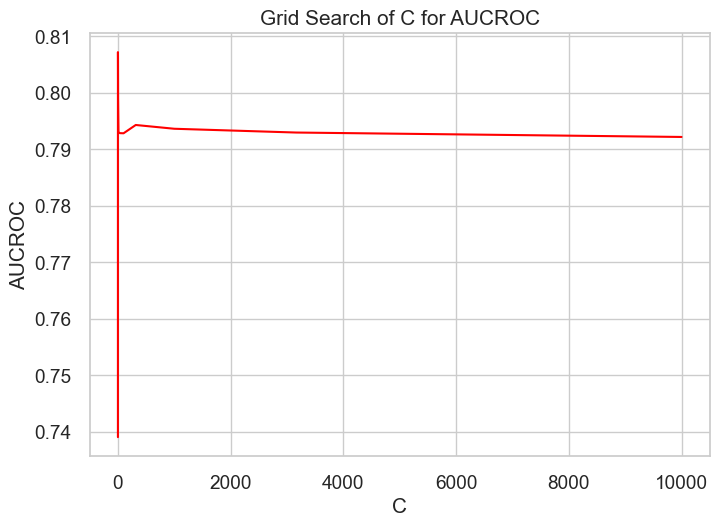

In [11]:
C_vals = [h[0] for h in hypers_list]
AUC_vals = [h[1] for h in hypers_list]
for C, AUC in zip(C_vals, AUC_vals):
    print(f"AUC of: {AUC} for C of: {C}")
plt.plot(C_vals, AUC_vals, color='red')
plt.xlabel('C')
plt.ylabel('AUCROC')
plt.title('Grid Search of C for AUCROC')

In [12]:
print(x_train_df.head())
print(x_train_df_new.head())
x_train_aug_df = pd.concat([x_train_df, x_train_df_new], axis=1)
x_train_aug_df = x_train_aug_df.fillna(0).iloc[: , 7:]
print(x_train_aug_df.head())
print(len(x_train_df_new))
print(len(x_train_df))

        author                  title  passage_id  \
0  A. A. Milne  The Red House Mystery         618   
1  A. A. Milne  The Red House Mystery         685   
2  A. A. Milne  The Red House Mystery         833   
3  A. A. Milne  The Red House Mystery         959   
4  A. A. Milne  The Red House Mystery        1019   

                                                text  char_count  word_count  \
0  "Yes.... What sort of terms was he on with the...       493.0       119.0   
1  Perhaps I should say that it was Mark's  priva...       318.0        61.0   
2  "Well, he had to mark the particular place by ...       521.0       133.0   
3  "I never ought to have asked you," said Antony...       481.0       118.0   
4  "And now," he said, "let's try and find out wh...       358.0        80.0   

   sentence_count  avg_word_length  avg_sentence_length  type_token_ratio  \
0             9.0         3.428571            13.222222          0.655462   
1             5.0         4.327869            

In [13]:
pl_all_cols = make_logit_pipeline(C=best_C, use_tfidf=False, sublinear_tf=False)
print(x_train_aug_df.isnull().any().any())

False


In [14]:
print(y_train_df['Coarse Label'].isnull().any().any())
pl_all_cols.fit(x_train_aug_df, y_train_df['Coarse Label'])

False


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('rescaler', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueSet to False to perform inplace scaling and avoid a copy (if the inputis already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data to [-1, 1].Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the [-1, 1] range, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....2776601683794)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Cert

In [15]:
x_test_aug_df = pd.concat([x_test_df, x_test_df_new], axis=1)
x_test_aug_df = x_test_aug_df.fillna(0).iloc[: , 7:]
y_test_pred_proba = pl_all_cols.predict_proba(x_test_aug_df)[:, 1]
with open("yproba1_test.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")
y_pred_proba = pl_all_cols.predict_proba(x_train_aug_df)[:, 1]
auc = sklearn.metrics.roc_auc_score(y_train_df['Coarse Label'], y_pred_proba)
print(auc)

0.9861639828899427


In [16]:
best_pl = make_logit_pipeline(C=1.0)
best_pl.fit(x_train_df_new, y_train_df['Coarse Label'])
y_test_pred_proba = best_pl.predict_proba(x_test_df_new)[:, 1]
with open("yproba1_test.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

In [17]:
# pl_no_vocab = make_logit_pipeline(C=best_C, use_tfidf=False, sublinear_tf=False)
# pl_no_vocab.fit(x_train_df.iloc[:, 7:], y_train_df['Coarse Label'])
# y_test_pred_proba = pl_no_vocab.predict_proba(x_test_df.iloc[: , 7:])[:, 1]
# with open("yproba1_test.txt", "w") as f:
#     for pred in y_test_pred_proba:
#         f.write(f"{pred}\n")